# 02 — Semantic Clustering Benchmark: 4 Strategies, 2 Corpora, Real Embeddings

R&D benchmark comparing 4 semantic segmentation strategies against the real embedding
provider (Ollama `nomic-embed-text`, 768 dims — no bag-of-words mock) on two very
different corpora:

- **Corpus A — book prose**: 128 pages / 293 chunks of *Marcus Aurelius: Meditations*.
  Clean paragraph structure, one long continuous argument.
- **Corpus B — spoken discourse**: a real YouTube video transcript. Filler, repetition,
  topic drift, no paragraph markers — a materially harder segmentation problem.

**The goal is semantic coherence, not uniform chunk size.** A single powerful one-chunk
idea and a 50-chunk passage about one central idea are equally valid note candidates.
So alongside cohesion/separation/contrast, every strategy is scored on its **segment
size range** — a narrow range is evidence the method is imposing artificial uniformity
rather than following where the content actually breaks.

In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import load_settings
from infrastructure.context import build_context
from notebooks._lib.embedding_cache import probe_provider

settings = load_settings()
ctx = build_context(settings)
probe_provider(ctx)
print("EgoVault Semantic Clustering Benchmark ready — embedding provider reachable.")

EgoVault Semantic Clustering Benchmark ready — embedding provider reachable.


## 1. Corpus A — Marcus Aurelius Meditations (book prose, 293 chunks)

Real Ollama embeddings, disk-cached (`notebooks/.cache/`) — first run embeds all 293
chunks (a few minutes), every subsequent run is instant.

In [24]:
from notebooks.demo_marcus_aurelius_segmentation import extract_pdf_text
from notebooks._lib.embedding_cache import get_or_embed
from notebooks._lib.segmentation_strategies import (
    run_benchmark, print_metrics_table, plot_strategy_bands,
    plot_metrics_comparison, plot_size_distribution, plot_pca_topology,
)
from tools.text.chunk import chunk_text

pdf_file = PROJECT_ROOT / "notebooks" / "assets" / "Marcus-Aurelius-Meditations.pdf"
full_text = extract_pdf_text(pdf_file)
chunks_book = chunk_text(full_text, settings.system)
print(f"Book corpus: {len(full_text.split())} words -> {len(chunks_book)} chunks")

embeddings_book = get_or_embed([c.content for c in chunks_book], ctx)
results_book, raw_cosines_book = run_benchmark(chunks_book, embeddings_book, settings, baseline_k=settings.system.note_segmentation.sensitivity_k)
print_metrics_table(results_book)

Book corpus: 76155 words -> 293 chunks
Embedding cache: 293 hits, 0 misses (model=nomic-embed-text, dims=768).
Strategy                          #Cand  Cohesion  Separation  Contrast  Size (min-max)   Runtime
-------------------------------------------------------------------------------------------------
Baseline TextTiling                  26    0.7850      0.7024    0.0826            3-40       55ms
Two-Stage Hierarchical Merging       14    0.7803      0.7258    0.0545           18-24       92ms
Constrained AHC (16 clusters)        16    0.7830      0.6847    0.0983            1-46       59ms
Gaussian Smoothed Minima             18    0.7810      0.7275    0.0535            3-52       53ms


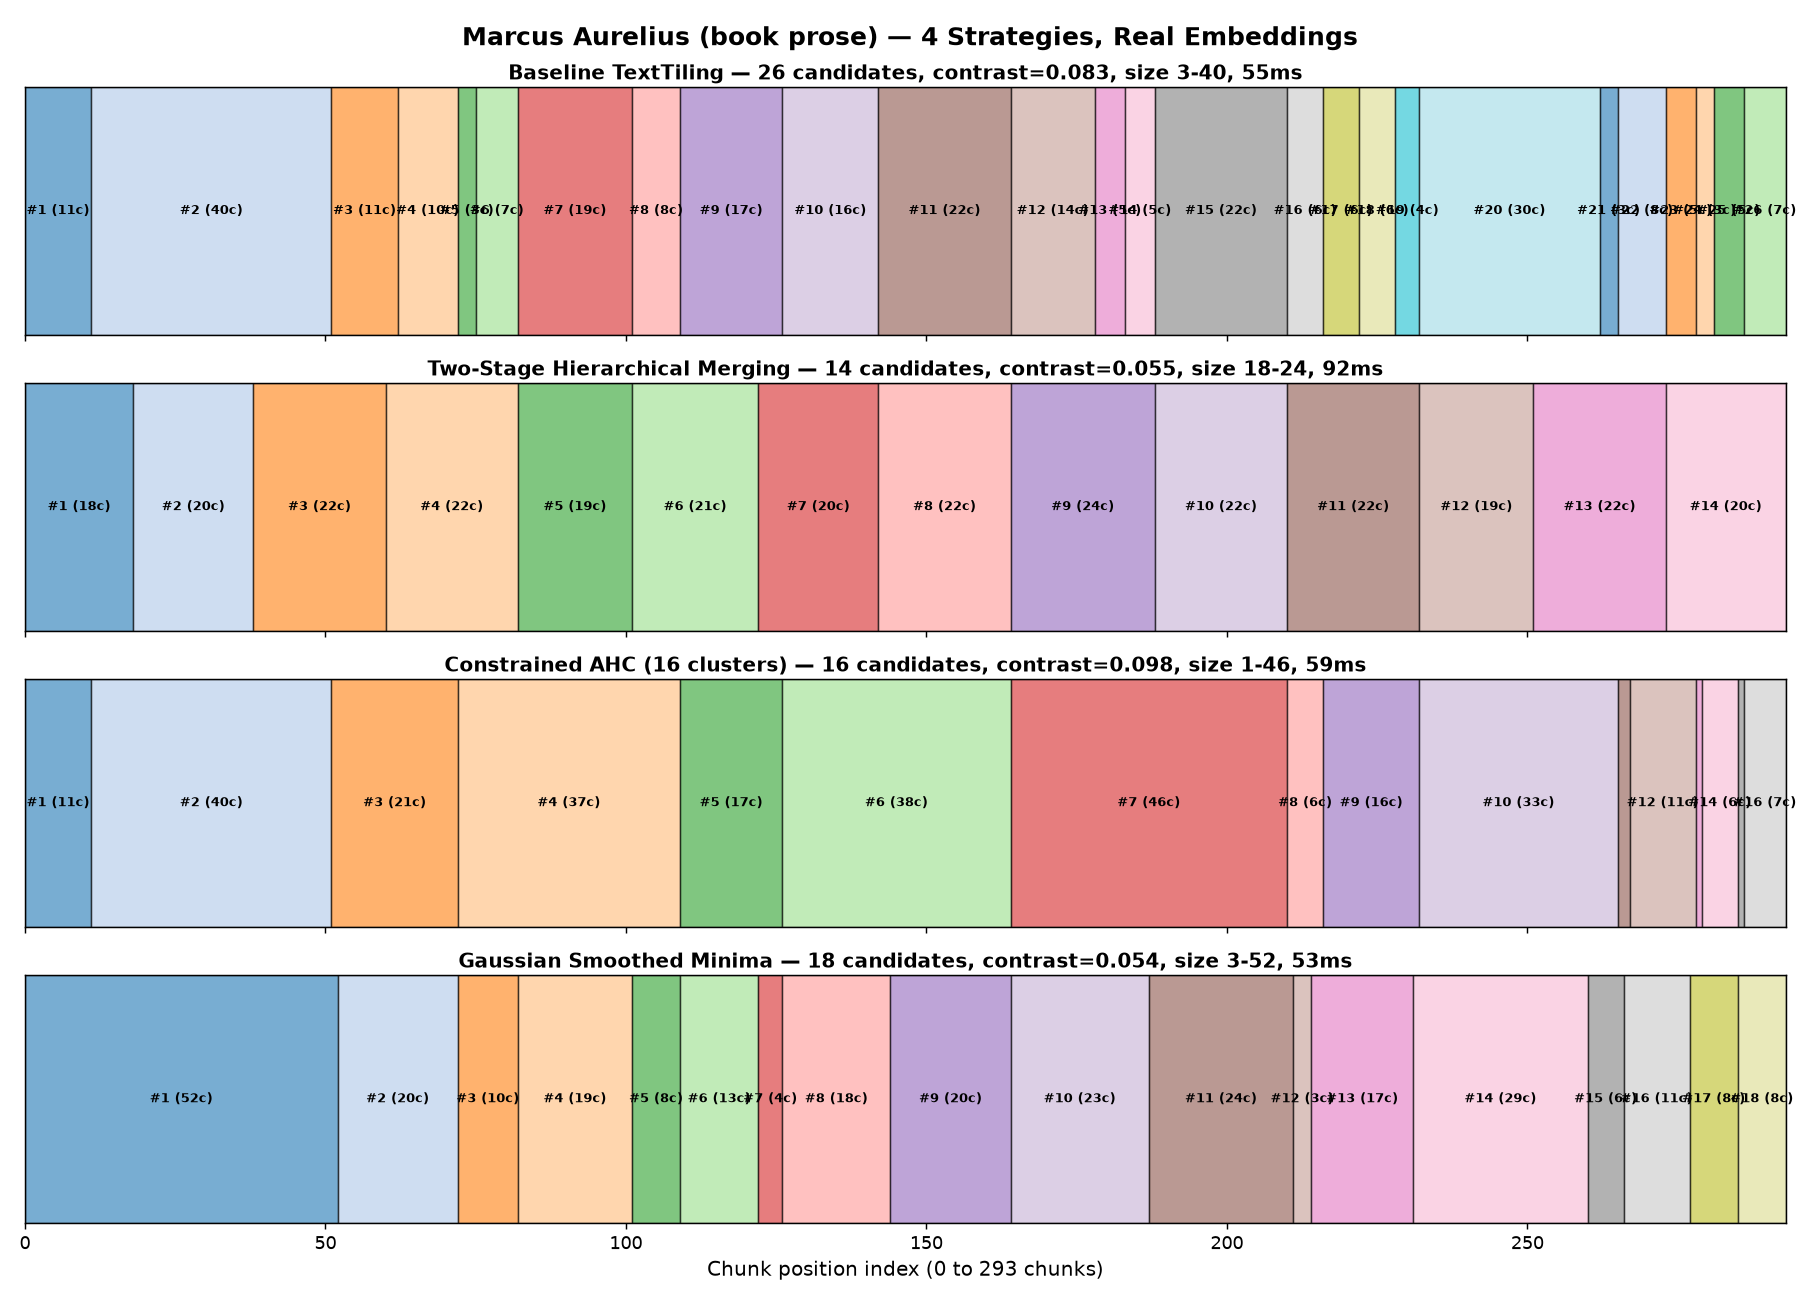

In [25]:
assets_dir = PROJECT_ROOT / "notebooks" / "assets"
assets_dir.mkdir(parents=True, exist_ok=True)

plot_strategy_bands(chunks_book, results_book, "Marcus Aurelius (book prose)", assets_dir / "clustering_4_strategies_benchmark.png")
plot_metrics_comparison(results_book, "Marcus Aurelius (book prose)", assets_dir / "clustering_metrics_comparison.png")
plot_size_distribution(results_book, "Marcus Aurelius (book prose)", assets_dir / "clustering_size_distribution.png")

two_stage_book = results_book["Two-Stage Hierarchical Merging"][0]
plot_pca_topology(chunks_book, embeddings_book, two_stage_book, 2, "Marcus Aurelius (book prose)", assets_dir / "clustering_2d_pca_topology.png")
plot_pca_topology(chunks_book, embeddings_book, two_stage_book, 3, "Marcus Aurelius (book prose)", assets_dir / "clustering_3d_pca_topology.png")

from IPython.display import Image, display
display(Image(filename=str(assets_dir / "clustering_4_strategies_benchmark.png")))

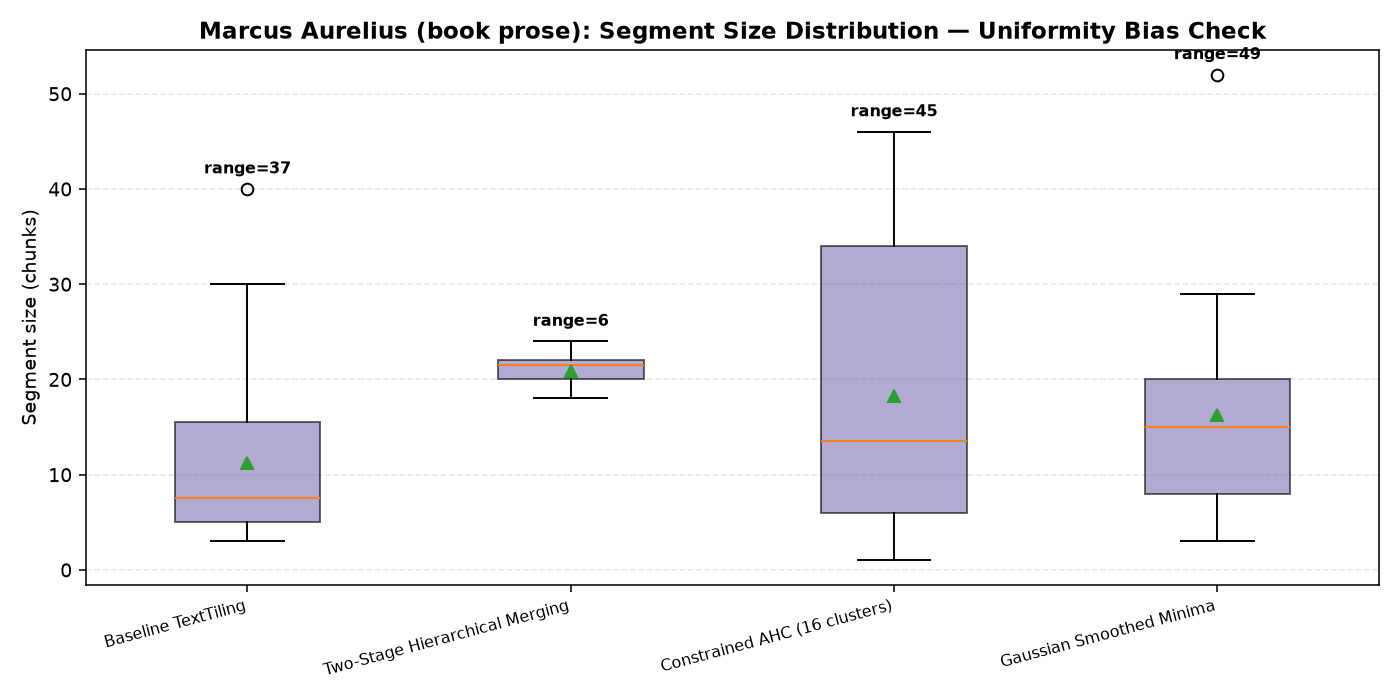

In [26]:
display(Image(filename=str(assets_dir / "clustering_size_distribution.png")))

**Reading the size-distribution chart:** `Two-Stage Hierarchical Merging` enforces a
narrow 18-24 chunk range by construction (its `min_chunks`/`max_chunks` merge caps) —
it cannot represent a 1-chunk idea next to a 40-chunk idea even if the content calls
for it. `Baseline TextTiling`, `Constrained AHC`, and `Gaussian Smoothed Minima` all
range from as low as 1 chunk up to 40-52 chunks — they let size emerge from the
semantic signal instead of forcing it.

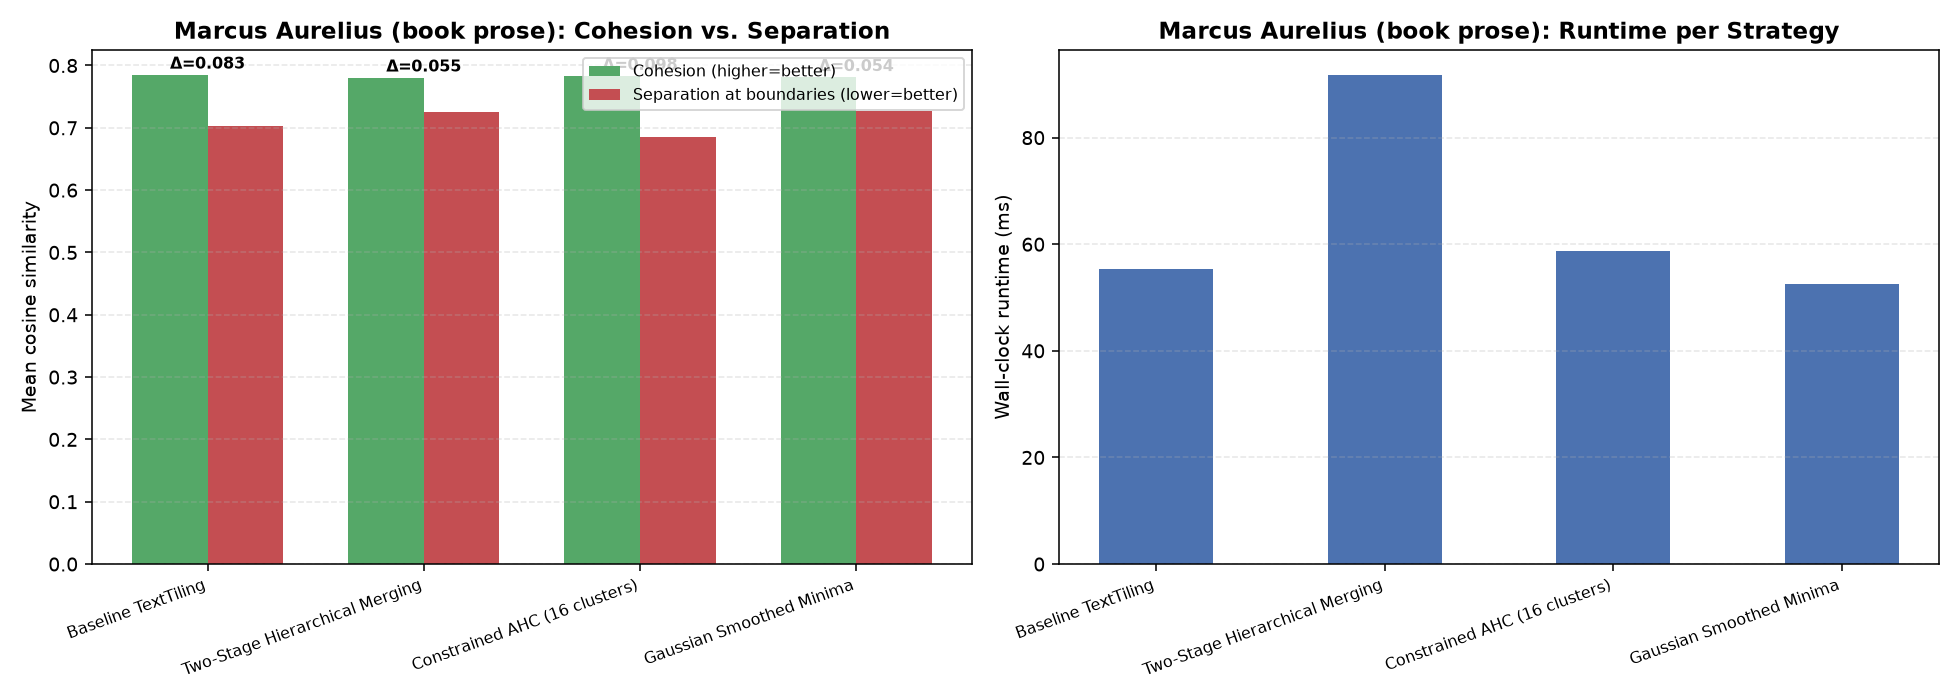

In [27]:
display(Image(filename=str(assets_dir / "clustering_metrics_comparison.png")))

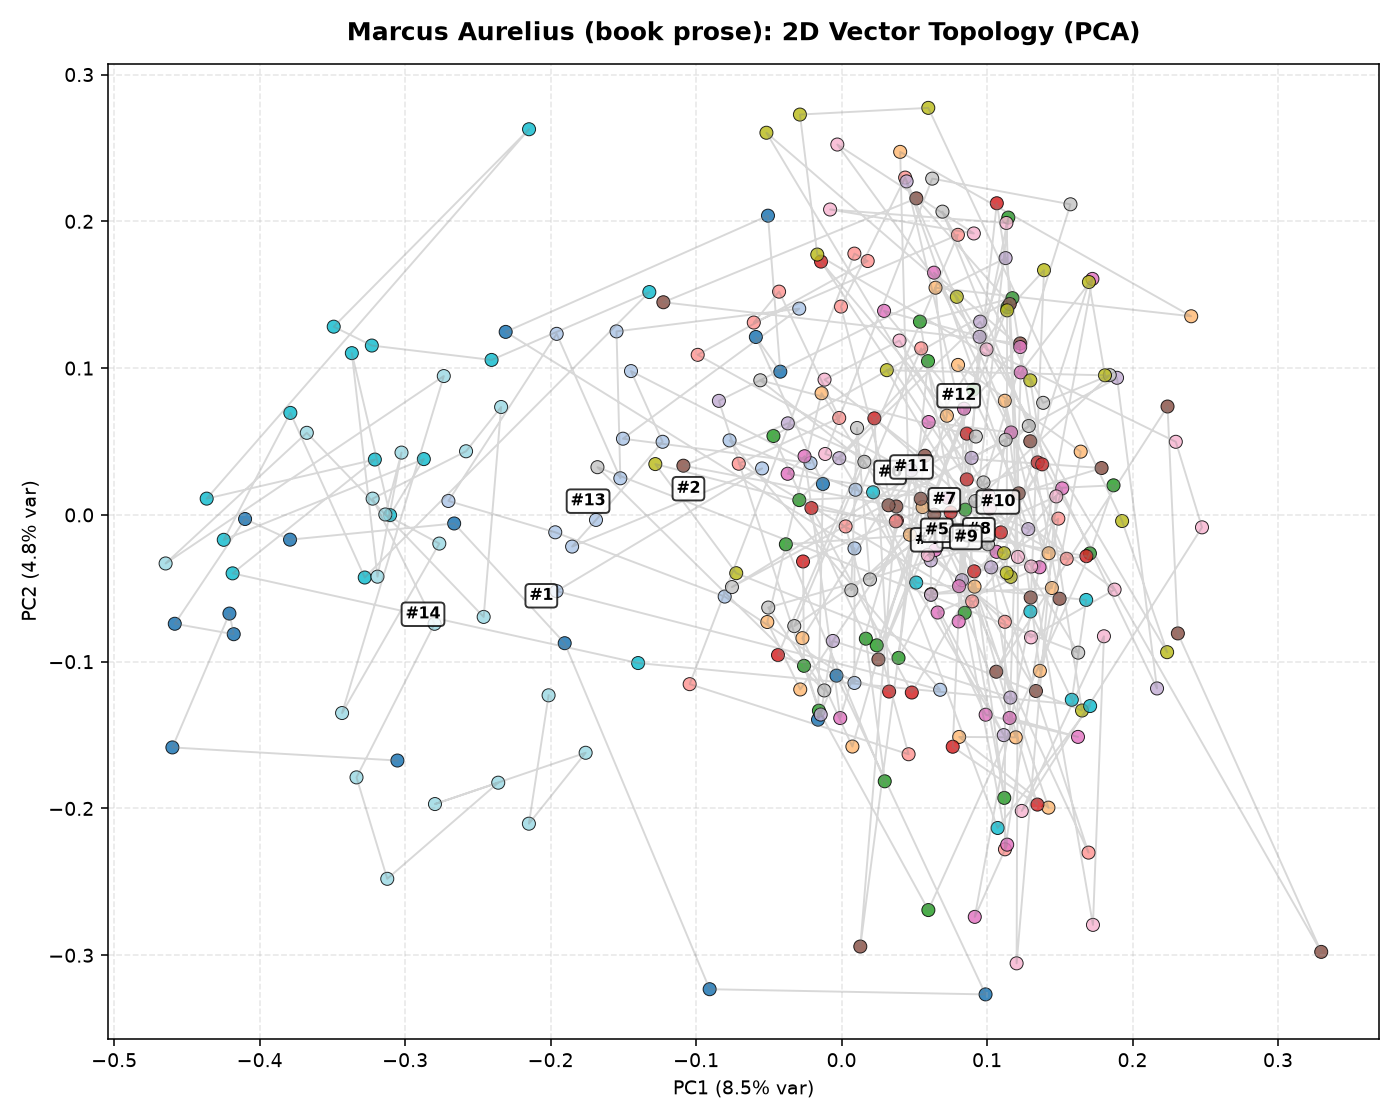

In [28]:
display(Image(filename=str(assets_dir / "clustering_2d_pca_topology.png")))

## 2. Corpus B — Spoken Discourse (real YouTube transcript, stress test)

Same 4 strategies, same real embedding provider, applied to a real spoken-word
transcript instead of edited book prose — a materially harder segmentation problem
(filler, repetition, topic drift, no paragraph markers).

In [29]:
from notebooks.demo_podcast_segmentation_benchmark import VIDEO_URL
from tools.media.fetch_subtitles import fetch_subtitles

print(f"Fetching subtitles for {VIDEO_URL} ...")
subs = fetch_subtitles(VIDEO_URL, ctx=ctx)
print(f"{len(subs.text.split())} words, language={subs.language}, source={subs.source}")

chunks_podcast = chunk_text(subs.text, settings.system)
print(f"Podcast corpus: {len(chunks_podcast)} chunks")

embeddings_podcast = get_or_embed([c.content for c in chunks_podcast], ctx)
results_podcast, raw_cosines_podcast = run_benchmark(chunks_podcast, embeddings_podcast, settings, baseline_k=settings.system.note_segmentation.sensitivity_k)
print_metrics_table(results_podcast)

Fetching subtitles for https://www.youtube.com/watch?v=5JDrK7sP3gA ...
1567 words, language=fr, source=subtitles
Podcast corpus: 7 chunks
Embedding cache: 7 hits, 0 misses (model=nomic-embed-text, dims=768).
Strategy                          #Cand  Cohesion  Separation  Contrast  Size (min-max)   Runtime
-------------------------------------------------------------------------------------------------
Baseline TextTiling                   1    0.7348         nan       nan             7-7        1ms
Two-Stage Hierarchical Merging        1    0.7348         nan       nan             7-7        2ms
Constrained AHC (2 clusters)          2    0.7904      0.4566    0.3338             1-6        3ms
Gaussian Smoothed Minima              1    0.7348         nan       nan             7-7        1ms


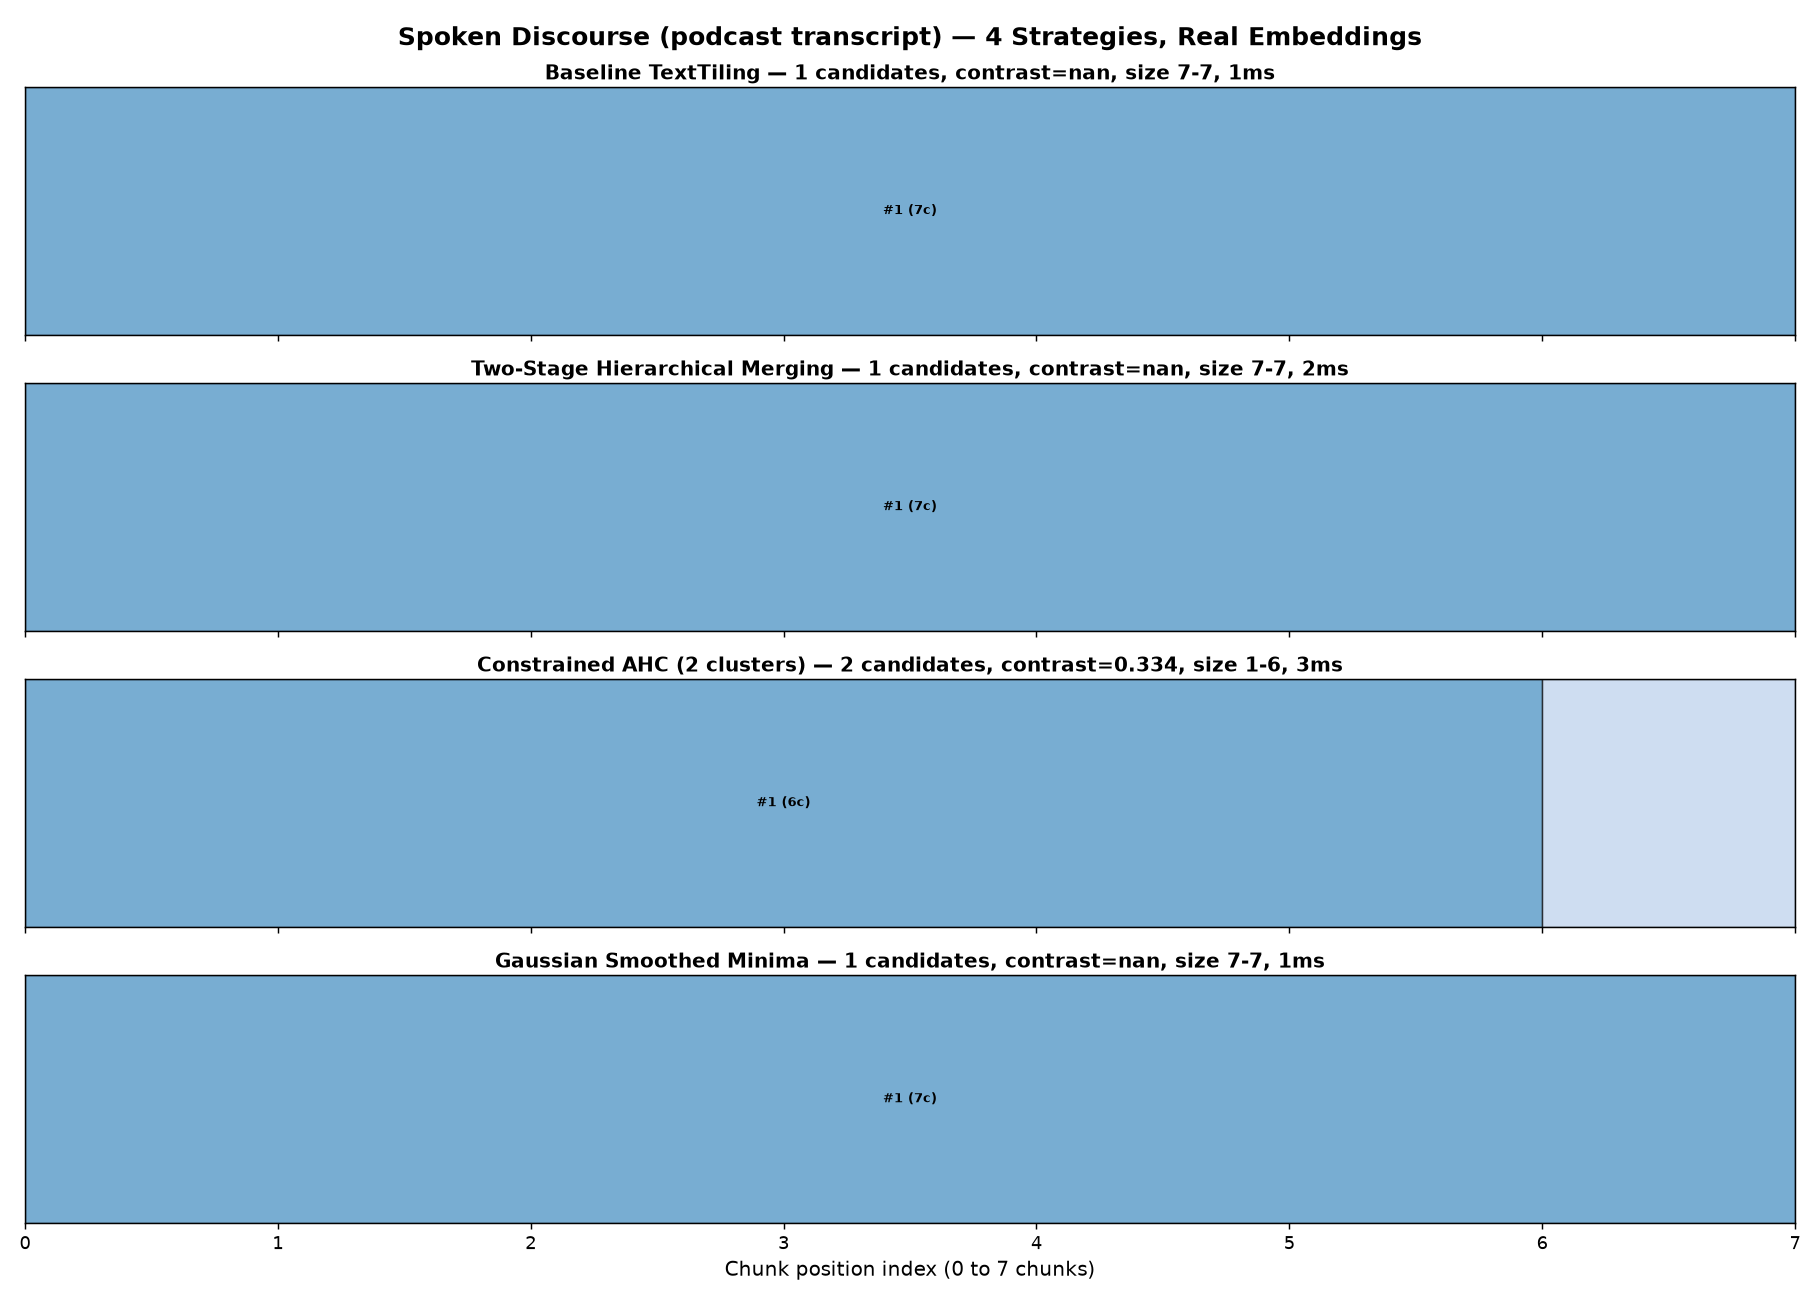

In [30]:
plot_strategy_bands(chunks_podcast, results_podcast, "Spoken Discourse (podcast transcript)", assets_dir / "podcast_4_strategies_benchmark.png")
plot_metrics_comparison(results_podcast, "Spoken Discourse (podcast transcript)", assets_dir / "podcast_metrics_comparison.png")
plot_size_distribution(results_podcast, "Spoken Discourse (podcast transcript)", assets_dir / "podcast_size_distribution.png")

display(Image(filename=str(assets_dir / "podcast_4_strategies_benchmark.png")))

**Reading this result:** this particular clip is short and stays on one topic
throughout — three of four strategies correctly settle on a single segment rather than
fragmenting a coherent idea for the sake of producing multiple notes. `Constrained AHC`
is the exception: it always targets a fixed number of clusters regardless of whether
the content actually contains multiple topics, so it force-splits the transcript into
2 pieces anyway. That is the uniformity-bias failure mode in its purest form — the
method imposes structure the content doesn't have.

## 3. Takeaway

No single strategy wins outright. `Constrained AHC` has the best boundary contrast on
the book corpus but is also the one strategy that force-segments content with no real
topic break (seen clearly on the podcast corpus). `Two-Stage Hierarchical Merging`
produces clean-looking output but is the most uniformity-biased by construction.
`Baseline TextTiling` (the production engine, unmodified) and `Gaussian Smoothed
Minima` both let segment size range from 1 chunk to 40+ chunks driven purely by the
cosine signal — closest to the actual goal of "one note per semantic nucleus,
whatever size that nucleus is."

This replaces the previous version of this notebook's single-line "Method 1
RECOMMENDED" verdict, which was computed on bag-of-words mock embeddings and
implicitly rewarded uniform chunk counts — neither of which reflects what the
production engine actually needs to optimize for.